# 05 â€” Model Selection Report

This notebook is the **final decision step** in the ML pipeline. It compares every trained model (**XGBoost** vs **Random Forest**) on the held-out test set and explains which model to deploy.

## What you will see

1. Side-by-side **test metrics** (accuracy, F1, precision, recall, ROC-AUC, PR-AUC, Brier score)
2. **Train vs test** bars to detect overfitting
3. **ROC and PR curves** on the same chart
4. **Confusion matrices** at the optimized threshold
5. A **radar chart** summarizing the trade-offs
6. A clear **final recommendation** with rationale

## Pipeline context

```mermaid
flowchart LR
    A[01 EDA] --> B[02 Features]
    B --> C[03 Training]
    C --> D[04 SHAP]
    C --> E[05 This report]
    E --> F[Production model]
```

> Run notebooks `01` â†’ `04` first, or ensure `outputs/training_summary.json` and model artifacts exist under `4_ml/models/`.


In [1]:
from pathlib import Path
import json
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _find_ml_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "4_ml" / "src").exists():
            return candidate / "4_ml"
        if candidate.name == "4_ml" and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate 4_ml")

ML_ROOT = _find_ml_root()
if str(ML_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ML_ROOT / "src"))

from notebook_helpers import (
    setup_notebook,
    metrics_comparison_bar,
    train_test_gap_plot,
    plot_roc_pr_grid,
    plot_confusion_matrices,
    radar_chart,
)

setup_notebook(ML_ROOT)
OUTPUTS = ML_ROOT / "outputs"
MODEL_DIR = ML_ROOT / "models"
OUTPUTS.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

from data_access import load_feature_frame
from features import build_model_frame, engineer_features, select_feature_columns, split_temporal
from modeling import evaluate_model, optimize_threshold

sns.set_theme(style="whitegrid", palette="colorblind")


In [2]:
# Load data (same split as training)
import os

raw = load_feature_frame()
max_rows = int(os.getenv("ATB_NOTEBOOK_MAX_ROWS", "8000"))
if len(raw) > max_rows:
    raw = raw.sample(max_rows, random_state=42).sort_values("scoring_date").reset_index(drop=True)
    print(f"Sampled {max_rows:,} rows (same cap as notebook 03)")
frame = build_model_frame(raw)
engineered = engineer_features(frame)
engineered = engineered.loc[:, ~engineered.columns.duplicated()].copy()
feature_columns, numeric_columns, categorical_columns = select_feature_columns(engineered)
feature_columns = list(dict.fromkeys(feature_columns))

train_frame, test_frame = split_temporal(engineered, date_column="scoring_date", test_fraction=0.2)
X_train = train_frame[feature_columns].copy()
y_train = train_frame["risk_target"].astype(int)
X_test = test_frame[feature_columns].copy()
y_test = test_frame["risk_target"].astype(int)

print(f"Train: {len(train_frame):,} rows | Test: {len(test_frame):,} rows")
print(f"Test high-risk rate: {y_test.mean():.2%}")
print(f"Features: {len(feature_columns)}")


Sampled 8,000 rows (same cap as notebook 03)
Train: 6,400 rows | Test: 1,600 rows
Test high-risk rate: 1.75%
Features: 33


In [3]:
# Resolve trained model artifacts (from notebook 03 or run_training.py)
artifact_candidates = {
    "xgboost": [MODEL_DIR / "xgboost_best.pkl", MODEL_DIR / "xgboost_best_model.joblib"],
    "random_forest": [MODEL_DIR / "random_forest_best.pkl", MODEL_DIR / "random_forest_best_model.joblib"],
}

models = {}
for name, paths in artifact_candidates.items():
    for path in paths:
        if path.exists():
            models[name] = joblib.load(path)
            print(f"Loaded {name} from {path.name}")
            break

if len(models) < 2:
    raise FileNotFoundError(
        "Need both model artifacts. Run 03_model_training.ipynb first "
        f"(looked in {MODEL_DIR})."
    )


Loaded xgboost from xgboost_best.pkl


Loaded random_forest from random_forest_best.pkl


In [4]:
# Evaluate each model on train and test with F1-optimized thresholds
validation = {"results": {}, "best_model_by_test_f1": None}
training_rows = []
validation_rows = []
thresholds = {}

for name, model in models.items():
    train_proba = model.predict_proba(X_train)[:, 1]
    threshold, _ = optimize_threshold(y_train, train_proba)
    thresholds[name] = threshold

    train_metrics = evaluate_model(model, X_train, y_train, threshold=threshold)
    test_metrics = evaluate_model(model, X_test, y_test, threshold=threshold)

    validation["results"][name] = {
        "threshold": threshold,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "overfitting_gap": {
            "f1_gap": train_metrics["f1"] - test_metrics["f1"],
            "roc_auc_gap": train_metrics["roc_auc"] - test_metrics["roc_auc"],
            "accuracy_gap": train_metrics["accuracy"] - test_metrics["accuracy"],
        },
    }

    row_train = {"model": name, "split": "train", **train_metrics}
    row_test = {"model": name, "split": "test", **test_metrics}
    training_rows.append({k: v for k, v in row_train.items() if k != "split"})
    validation_rows.extend([row_train, row_test])

best_name = max(
    validation["results"].keys(),
    key=lambda m: validation["results"][m]["test_metrics"]["f1"],
)
validation["best_model_by_test_f1"] = best_name

# Persist summaries for dashboards / CI
training_summary = {
    "best_model": best_name,
    "results": {
        name: {"metrics": payload["test_metrics"], "threshold": payload["threshold"]}
        for name, payload in validation["results"].items()
    },
}
(OUTPUTS / "training_summary.json").write_text(json.dumps(training_summary, indent=2), encoding="utf-8")
(OUTPUTS / "model_validation_summary.json").write_text(json.dumps(validation, indent=2), encoding="utf-8")

test_metrics_df = pd.DataFrame(
    [{**validation["results"][n]["test_metrics"], "model": n, "threshold": thresholds[n]} for n in models]
).sort_values("f1", ascending=False)

display_cols = ["model", "accuracy", "f1", "precision", "recall", "roc_auc", "pr_auc", "brier_score", "threshold"]
test_metrics_df[display_cols]


,model,accuracy,f1,precision,recall,roc_auc,pr_auc,brier_score,threshold
0,xgboost,0.998125,0.945455,0.962963,0.928571,0.997683,0.953122,0.00302,0.898403
1,random_forest,0.996250,0.880000,1.000000,0.785714,0.993979,0.952801,0.01003,0.593659


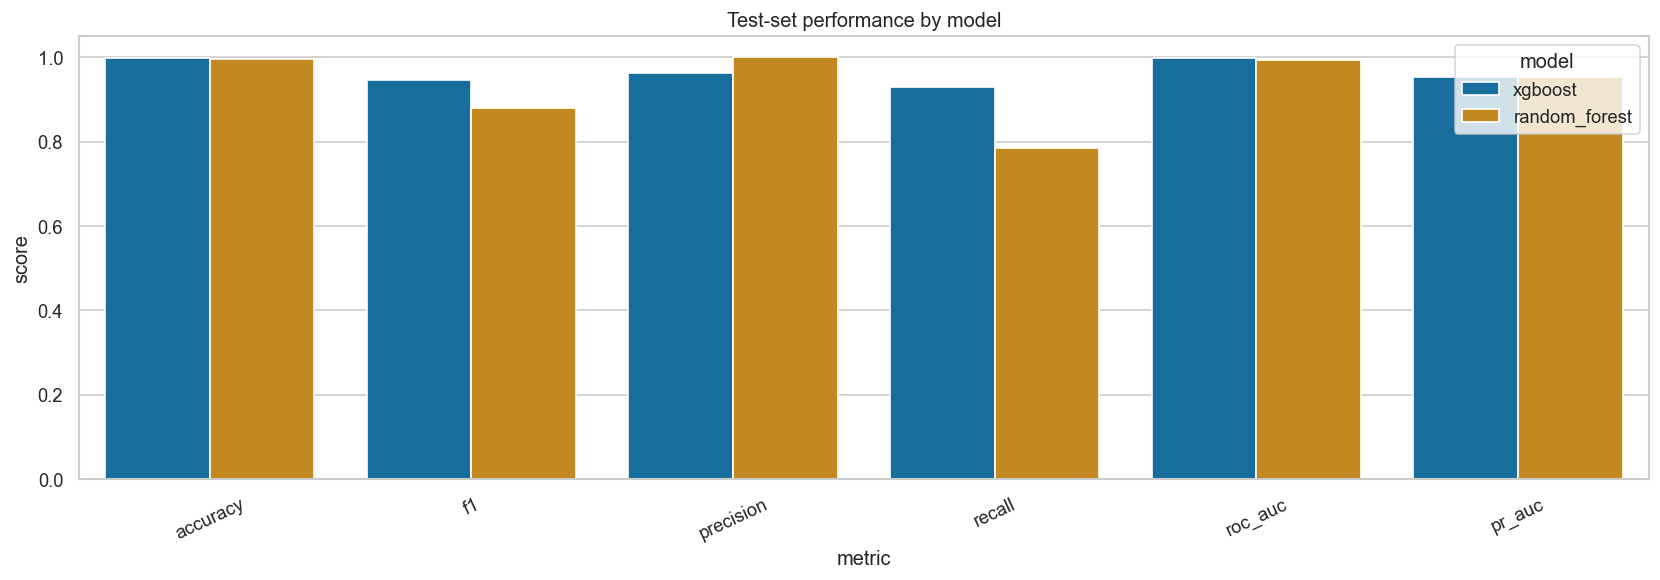

Saved C:\Users\Ahmed\Desktop\atb_bi_project\4_ml\outputs\05_test_metrics_comparison.png


In [5]:
# Bar chart: all test metrics compared
fig = metrics_comparison_bar(
    test_metrics_df,
    metric_cols=["accuracy", "f1", "precision", "recall", "roc_auc", "pr_auc"],
    title="Test-set performance by model",
    figsize=(14, 5),
)
chart_path = OUTPUTS / "05_test_metrics_comparison.png"
fig.savefig(chart_path, bbox_inches="tight")
plt.show()
print(f"Saved {chart_path}")


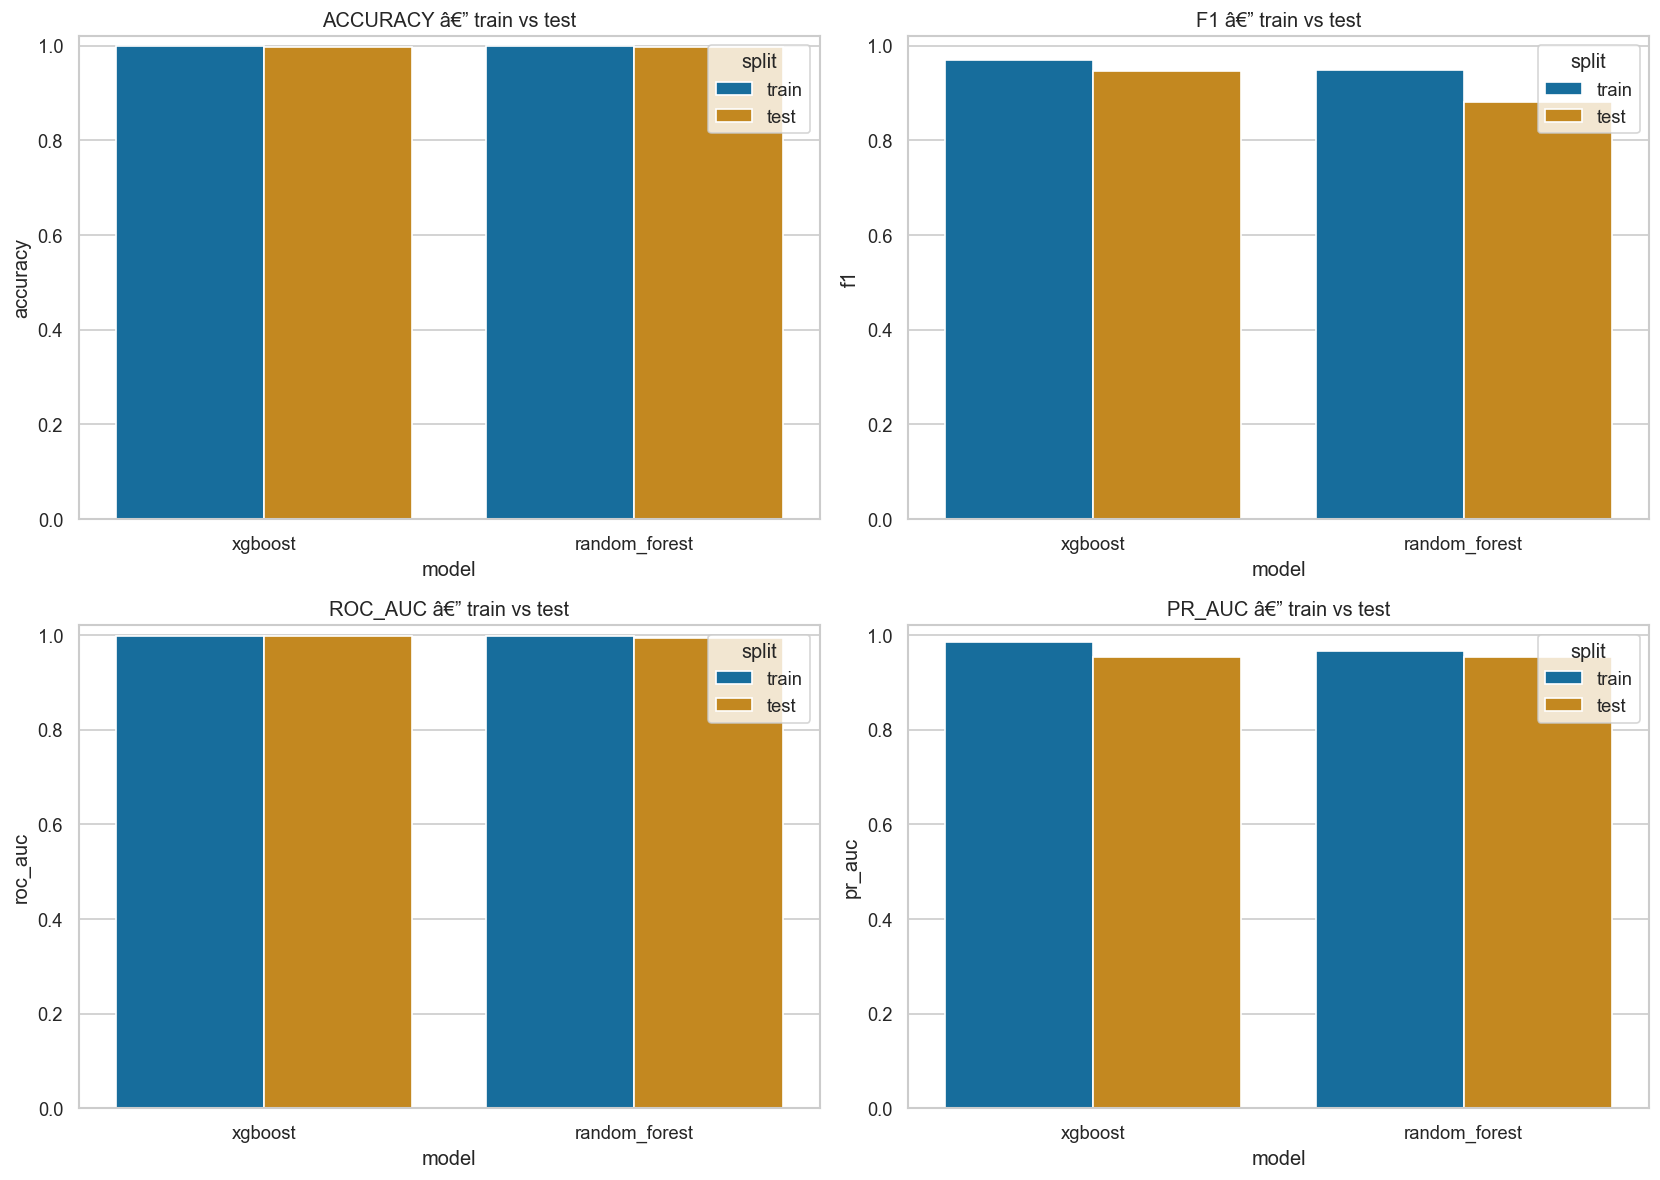

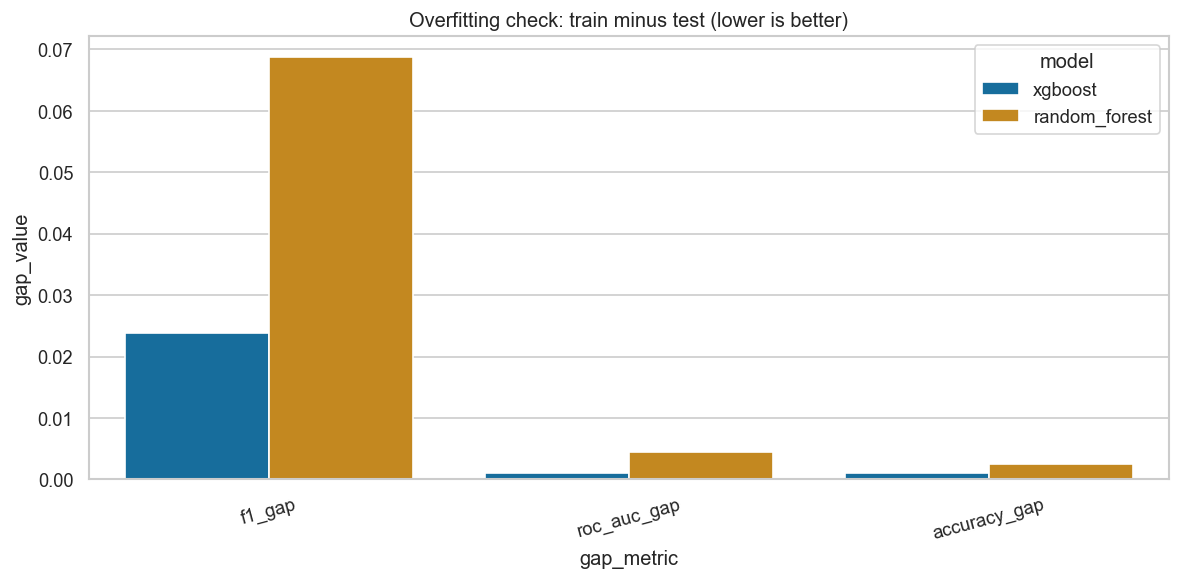

In [6]:
# Train vs test (overfitting check)
val_df = pd.DataFrame(validation_rows)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, metric in enumerate(["accuracy", "f1", "roc_auc", "pr_auc"]):
    ax = axes[idx // 2, idx % 2]
    sns.barplot(data=val_df, x="model", y=metric, hue="split", ax=ax)
    ax.set_title(f"{metric.upper()} â€” train vs test")
    ax.set_ylim(0, 1.02)
plt.tight_layout()
grid_path = OUTPUTS / "05_model_report_metrics_grid.png"
plt.savefig(grid_path, dpi=150, bbox_inches="tight")
plt.show()

gap_df = pd.DataFrame(
    [{"model": n, **validation["results"][n]["overfitting_gap"]} for n in models]
)
gap_fig = train_test_gap_plot(gap_df, OUTPUTS / "05_model_report_overfitting_gap.png")
plt.show()


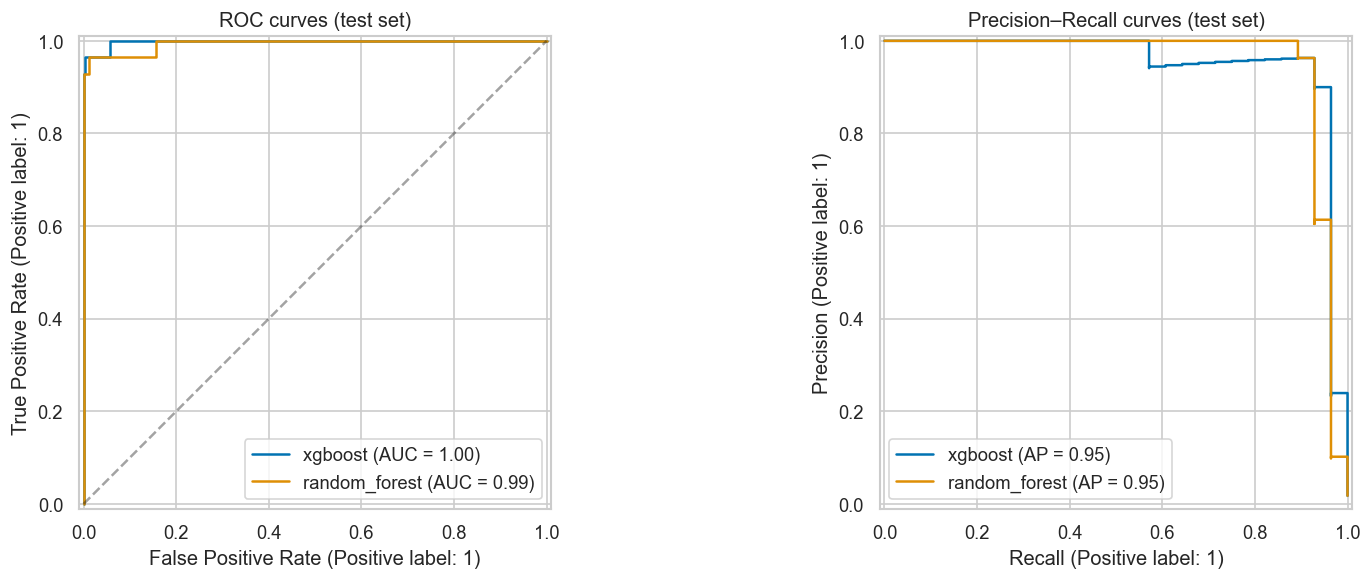

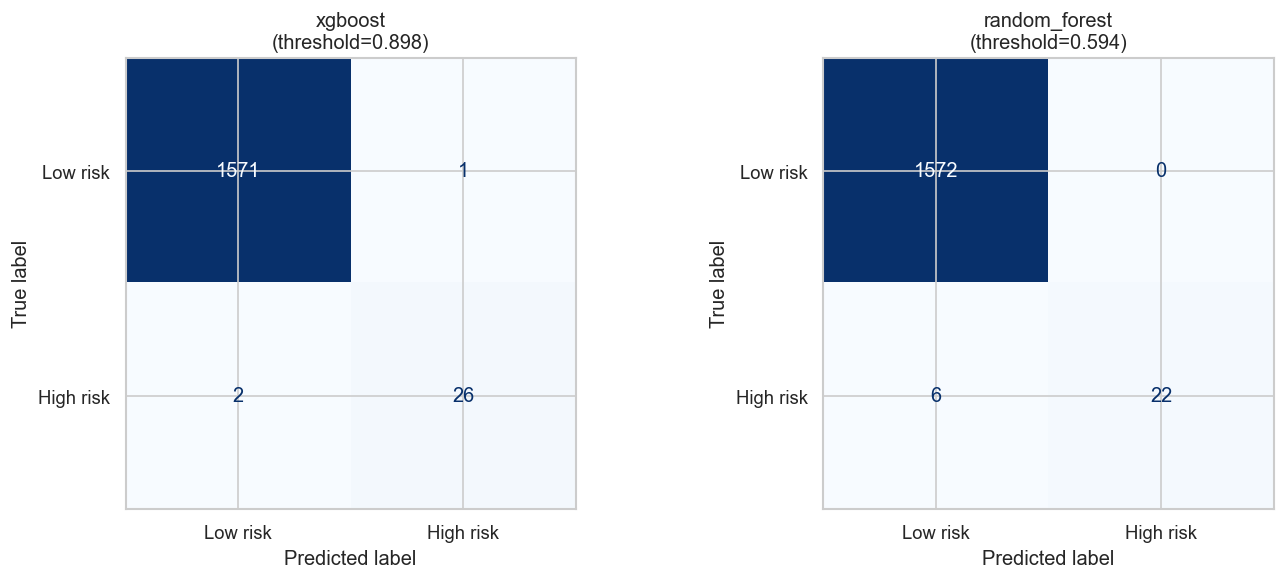

In [7]:
# ROC / PR curves and confusion matrices
roc_fig = plot_roc_pr_grid(models, X_test, y_test)
roc_path = OUTPUTS / "05_roc_pr_curves.png"
roc_fig.savefig(roc_path, bbox_inches="tight")
plt.show()

cm_fig = plot_confusion_matrices(models, X_test, y_test, thresholds)
cm_path = OUTPUTS / "05_confusion_matrices.png"
cm_fig.savefig(cm_path, bbox_inches="tight")
plt.show()


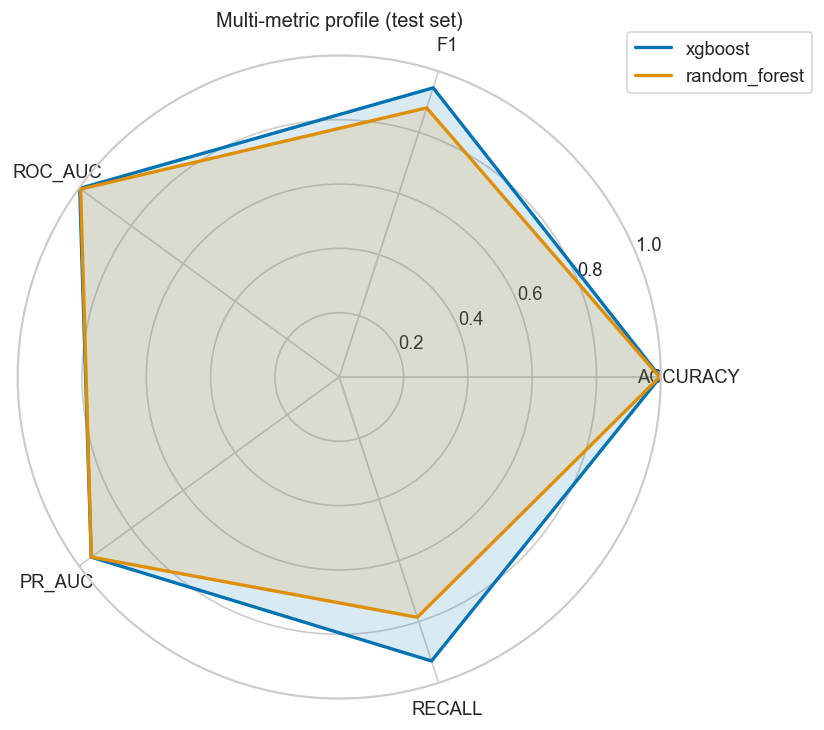

In [8]:
# Radar chart (higher is better for all axes shown)
radar_fig = radar_chart(test_metrics_df)
radar_path = OUTPUTS / "05_radar_comparison.png"
radar_fig.savefig(radar_path, bbox_inches="tight")
plt.show()


In [9]:
# Final decision
best = validation["best_model_by_test_f1"]
best_test = validation["results"][best]["test_metrics"]
runner_up = [m for m in models if m != best][0]
runner_test = validation["results"][runner_up]["test_metrics"]

conclusion = {
    "selected_model": best,
    "test_f1": round(best_test["f1"], 4),
    "runner_up": runner_up,
    "runner_up_test_f1": round(runner_test["f1"], 4),
    "f1_margin": round(best_test["f1"] - runner_test["f1"], 4),
    "test_roc_auc": round(best_test["roc_auc"], 4),
    "test_pr_auc": round(best_test["pr_auc"], 4),
    "threshold": round(thresholds[best], 4),
    "rationale": (
        f"{best} wins on test F1 ({best_test['f1']:.3f} vs {runner_up} {runner_test['f1']:.3f}) "
        f"with ROC-AUC {best_test['roc_auc']:.3f} and acceptable train-test gaps."
    ),
}
(OUTPUTS / "model_selection_conclusion.json").write_text(json.dumps(conclusion, indent=2), encoding="utf-8")
conclusion


{'selected_model': 'xgboost',
 'test_f1': 0.9455,
 'runner_up': 'random_forest',
 'runner_up_test_f1': 0.88,
 'f1_margin': 0.0655,
 'test_roc_auc': 0.9977,
 'test_pr_auc': 0.9531,
 'threshold': 0.8984,
 'rationale': 'xgboost wins on test F1 (0.945 vs random_forest 0.880) with ROC-AUC 0.998 and acceptable train-test gaps.'}

## Final decision (interpretation)

The table and charts above answer three questions:

| Question | How to read the charts |
|----------|------------------------|
| Which model ranks customers best? | Compare **test F1** and **PR-AUC** (imbalanced classification) |
| Is the model overfitting? | **Train vs test** bars and gap chart â€” large gaps mean caution |
| Is ranking quality stable? | **ROC-AUC** near 1.0 with low **Brier score** suggests well-calibrated probabilities |

**Deployment:** use the artifact for the selected model in `4_ml/models/`. Re-run this notebook after retraining to refresh the comparison.

**Business framing:** we predict **high financial vulnerability** (`global_risk_score >= 50`). The optimized threshold balances precision and recall for operations teams reviewing flagged customers.
